##Preparación de ciertas columnas y extracción de datos

In [0]:
import pandas as pd
import numpy as np
import pyspark.sql.functions as F

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [0]:
print("--- 1. Ingeniería de Variables en PySpark y Transición ---")

# 1.1 Extracción de características temporales antes de descargar a local
df_citas = spark.table("default.citas_pmm_limpioV2")
df_prep = df_citas.filter(F.col("estado_cita") == "Completada") \
                  .withColumn("mes", F.month("fecha_cit")) \
                  .withColumn("dia_semana", F.dayofweek("fecha_cit"))

# 1.2 Descartamos los componentes del pago total
columns_to_drop = ["pago_clie", "pago_aseg", "estado_cita", 
                "fecha_cit", "hr_inicio_cit", "hr_fin_cit", 
                "nom_comp_pac", "nom_comp_doc","tipo_sangre", 
                "nom_aseguradora"]
df_prep = df_prep.drop(*columns_to_drop)

# 1.3 Transferencia a memoria local (Pandas)
# Al ejecutar esto, los datos pasan del clúster/gestor de Spark a tu RAM de 32GB
print("Transfiriendo DataFrame a memoria local (Pandas)...")
df_local = df_prep.toPandas()

--- 1. Ingeniería de Variables en PySpark y Transición ---
Transfiriendo DataFrame a memoria local (Pandas)...


In [0]:
print("\n--- 2. Configuración del Pipeline de Preprocesamiento ---")

# 2.1 Definición del Target y Features
target_col = "pago_total"
X = df_local.drop(columns=[target_col])
y = df_local[target_col]

# 2.2 Segmentación de tipos de datos
cols_numericas = ["edad_pac_cita", "mins_cit"]
cols_categoricas = ["motivo_cita", "sexo_pac", "especialidad_medica", "nom_sucursal"]


# 2.3 Transformadores Nativos
# Para variables numéricas: Imputamos nulos con la mediana.
numeric_transformer = SimpleImputer(strategy="median")

# handle_unknown='ignore' evita que el modelo falle en producción si recibe una nueva sucursal.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 2.4 Ensamblador de Columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, cols_numericas),
        ('cat', categorical_transformer, cols_categoricas)
    ])

print("\n--- 3. Entrenamiento del Modelo XGBoost ---")

# 3.1 Particionamiento (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3.2 Definición del Algoritmo (Optimizando uso de hardware)
xgb_model = XGBRegressor(
    n_estimators=180,
    max_depth=4, # Profundidad para que el modelo generalice
    learning_rate=0.03,
    reg_alpha=10,              # L1 regularization: fuerza a los pesos a ser cero
    reg_lambda=10,             # L2 regularization: penaliza pesos muy grandes
    objective='reg:squarederror',
    device='cpu',
    n_jobs =-1,
    random_state=42
)

# 3.3 Integración del Pipeline Final
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

# 3.4 Entrenamiento
print("Entrenando el modelo...")
pipeline.fit(X_train, y_train)


--- 2. Configuración del Pipeline de Preprocesamiento ---

--- 3. Entrenamiento del Modelo XGBoost ---
Entrenando el modelo...


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['edad_pac_cita', 'peso_kg',
                                                   'altura_m', 'imc',
                                                   'mins_cit', 'mes',
                                                   'dia_semana']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['motiv...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.03,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=180, n_jobs=-1,
                              num_parallel_tree=None, ...))])

##Evaluación de los resultados

In [0]:
print("\n--- 4. Evaluación de Métricas de Negocio ---")

# Inferencia sobre el set de prueba (Validación Out-of-Sample)
predicciones = pipeline.predict(X_test)

# Cálculo de métricas
mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))
r2 = r2_score(y_test, predicciones)

print(f"Error Absoluto Medio (MAE): ${mae:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): ${rmse:.2f}")
print(f"Coeficiente de Determinación (R2): {r2:.4f}")


--- 4. Evaluación de Métricas de Negocio ---
Error Absoluto Medio (MAE): $5.05
Raíz del Error Cuadrático Medio (RMSE): $5.49
Coeficiente de Determinación (R2): 0.8443


## Evaluación gráfica del modelo


--- 5. Generación de Gráficas de Validación y Diagnóstico ---


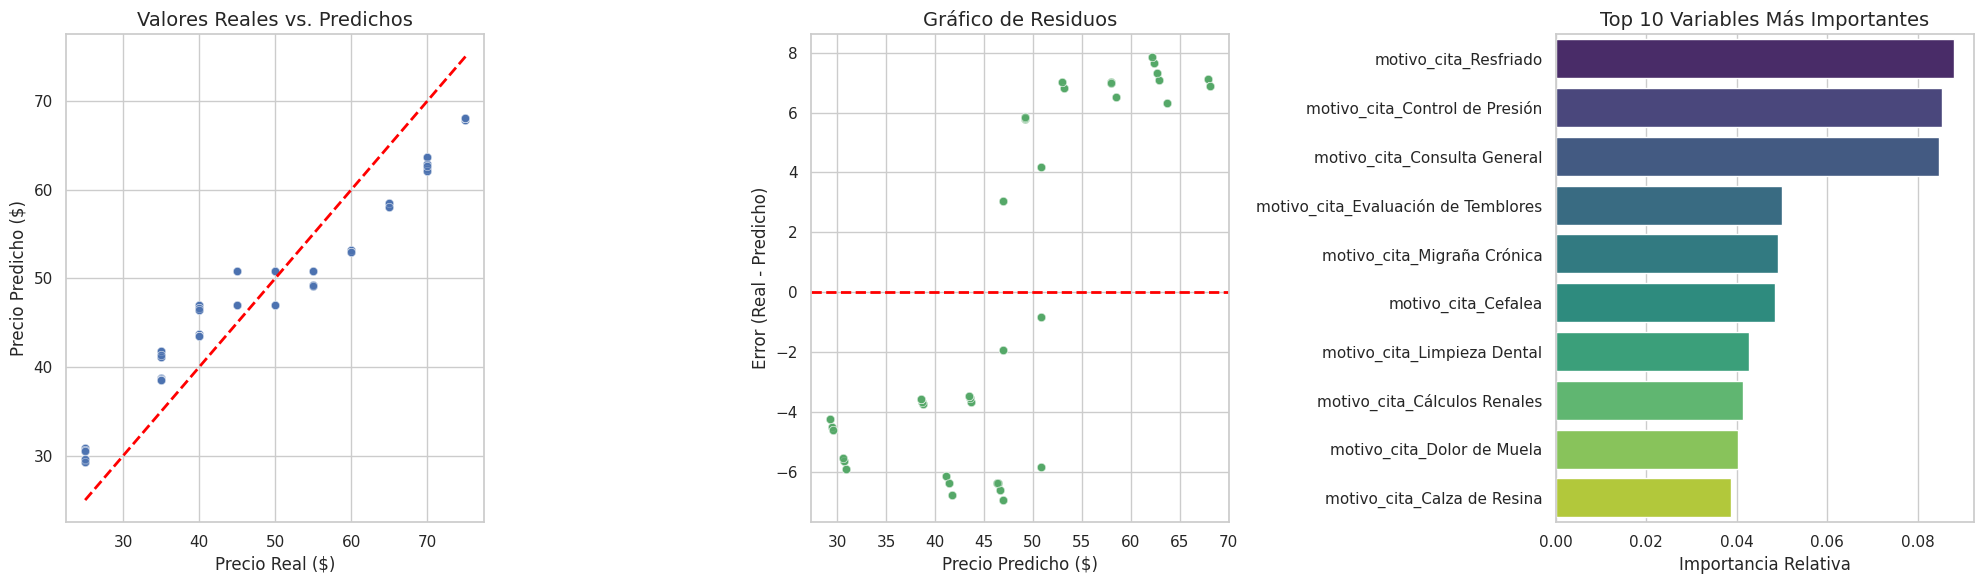

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- 5. Generación de Gráficas de Validación y Diagnóstico ---")

# Configuración de estilo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ---------------------------------------------------------
# GRÁFICA 1: Valores Reales vs Predichos
# ---------------------------------------------------------
sns.scatterplot(x=y_test, y=predicciones, alpha=0.5, ax=axes[0], color='b')
# Línea de referencia ideal (Predicción perfecta)
perfect_line = [y_test.min(), y_test.max()]
axes[0].plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2)
axes[0].set_title("Valores Reales vs. Predichos", fontsize=14)
axes[0].set_xlabel("Precio Real ($)", fontsize=12)
axes[0].set_ylabel("Precio Predicho ($)", fontsize=12)

# ---------------------------------------------------------
# GRÁFICA 2: Análisis de Residuos
# ---------------------------------------------------------
residuos = y_test - predicciones
sns.scatterplot(x=predicciones, y=residuos, alpha=0.5, ax=axes[1], color='g')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title("Gráfico de Residuos", fontsize=14)
axes[1].set_xlabel("Precio Predicho ($)", fontsize=12)
axes[1].set_ylabel("Error (Real - Predicho)", fontsize=12)

# ---------------------------------------------------------
# GRÁFICA 3: Importancia de las Variables (Feature Importance)
# ---------------------------------------------------------
# Extraer nombres de columnas del preprocesador
cat_encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_cat_cols = list(cat_encoder.get_feature_names_out(cols_categoricas))
todas_las_columnas = cols_numericas + encoded_cat_cols

# Obtener importancias del modelo XGBoost
importancias = pipeline.named_steps['model'].feature_importances_

# Crear DataFrame y seleccionar las top 10 más importantes
df_importancia = pd.DataFrame({'Variable': todas_las_columnas, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

sns.barplot(x='Importancia', y='Variable', data=df_importancia, ax=axes[2], hue='Variable', palette='viridis', legend=False)
axes[2].set_title("Top 10 Variables Más Importantes", fontsize=14)
axes[2].set_xlabel("Importancia Relativa", fontsize=12)
axes[2].set_ylabel("", fontsize=12)

plt.tight_layout()
plt.show()



--- 5. Generación de Gráficas de Validación Estructurales ---


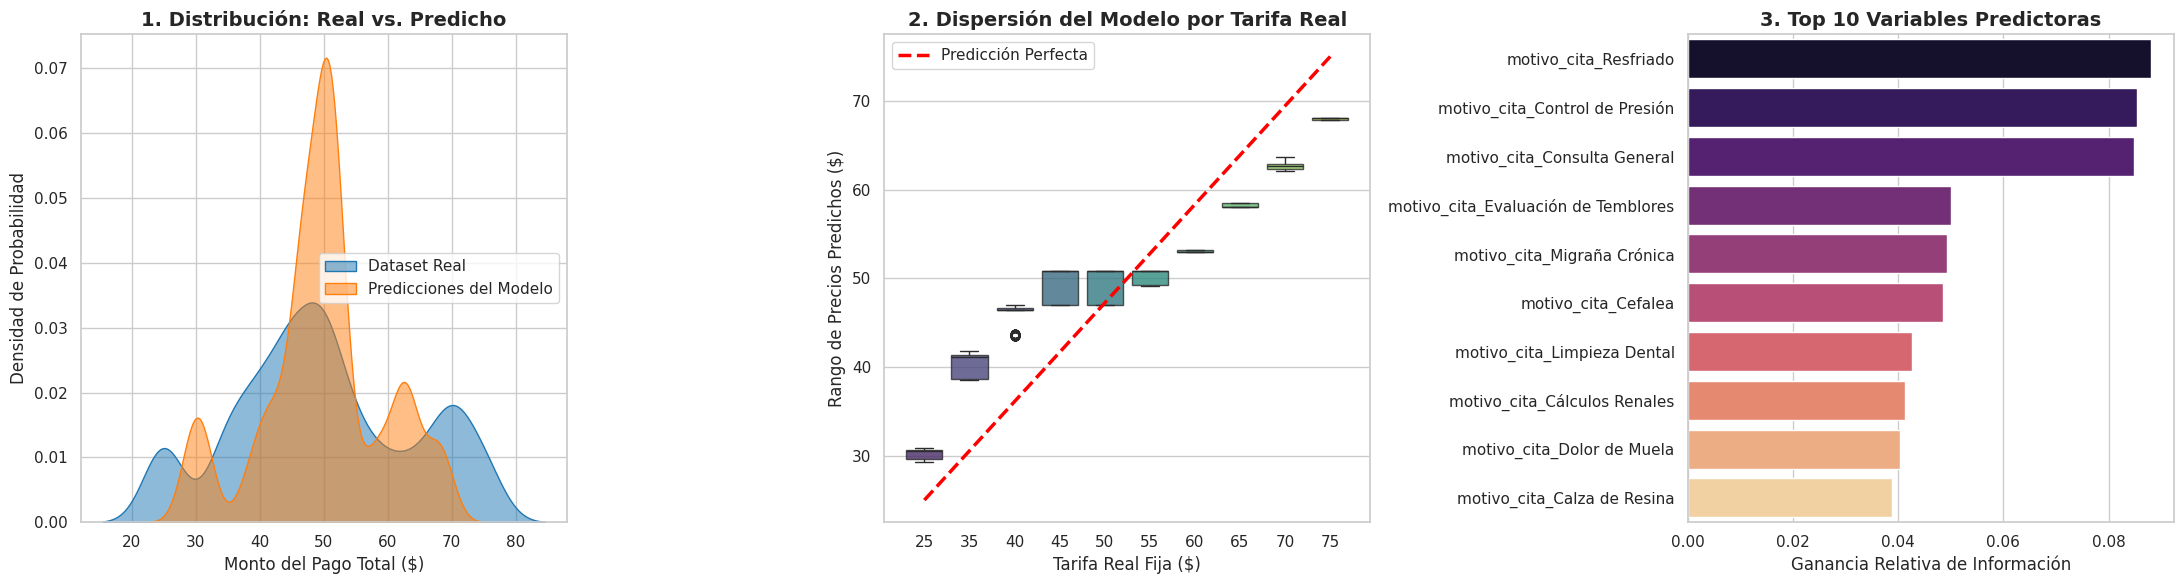

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("\n--- 5. Generación de Gráficas de Validación Estructurales ---")

# Configuración de estilo y dimensiones
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Preparar DataFrame consolidado para facilitar la graficación de Seaborn
df_eval = pd.DataFrame({
    'Precio_Real': y_test.values, 
    'Precio_Predicho': predicciones
})

# ---------------------------------------------------------
# GRÁFICA 1: Comparativa de Distribuciones (KDE Plot)
# ---------------------------------------------------------
# Esta gráfica te permite ver si el modelo está sub-prediciendo o sobre-prediciendo volumen
sns.kdeplot(data=df_eval, x='Precio_Real', label='Dataset Real', fill=True, ax=axes[0], color='#1f77b4', alpha=0.5)
sns.kdeplot(data=df_eval, x='Precio_Predicho', label='Predicciones del Modelo', fill=True, ax=axes[0], color='#ff7f0e', alpha=0.5)

axes[0].set_title("1. Distribución: Real vs. Predicho", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Monto del Pago Total ($)", fontsize=12)
axes[0].set_ylabel("Densidad de Probabilidad", fontsize=12)
axes[0].legend()

# ---------------------------------------------------------
# GRÁFICA 2: Varianza de Predicción por Nivel de Precio (Boxplot)
# ---------------------------------------------------------
# Redondeamos los reales temporalmente para el eje X por si hay decimales residuales
df_eval['Tarifa_Base'] = df_eval['Precio_Real'].round(0).astype(int)
tarifas_unicas = sorted(df_eval['Tarifa_Base'].unique())

sns.boxplot(x='Tarifa_Base', y='Precio_Predicho', data=df_eval, ax=axes[1], palette='viridis', boxprops=dict(alpha=0.8))

# Trazar la línea ideal de predicción (diagonal adaptada al formato de caja)
axes[1].plot([0, len(tarifas_unicas)-1], [min(tarifas_unicas), max(tarifas_unicas)], 
             color='red', linestyle='--', linewidth=2.5, label='Predicción Perfecta')

axes[1].set_title("2. Dispersión del Modelo por Tarifa Real", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Tarifa Real Fija ($)", fontsize=12)
axes[1].set_ylabel("Rango de Precios Predichos ($)", fontsize=12)
axes[1].legend()

# ---------------------------------------------------------
# GRÁFICA 3: Importancia de las Variables (Feature Importance)
# ---------------------------------------------------------
# Extraer nombres lógicos del preprocesador de Scikit-Learn
cat_encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_cat_cols = list(cat_encoder.get_feature_names_out(cols_categoricas))
todas_las_columnas = cols_numericas + encoded_cat_cols

# Extracción de pesos de XGBoost
importancias = pipeline.named_steps['model'].feature_importances_

df_importancia = pd.DataFrame({'Variable': todas_las_columnas, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

# Limpieza de nombres largos (opcional, para estética)
df_importancia['Variable'] = df_importancia['Variable'].str.replace('especialidad_medica_', 'Espec: ')
df_importancia['Variable'] = df_importancia['Variable'].str.replace('estado_cita_', 'Estado: ')

sns.barplot(x='Importancia', y='Variable', data=df_importancia, ax=axes[2], hue='Variable', palette='magma', legend=False)
axes[2].set_title("3. Top 10 Variables Predictoras", fontsize=14, fontweight='bold')
axes[2].set_xlabel("Ganancia Relativa de Información", fontsize=12)
axes[2].set_ylabel("", fontsize=12)

plt.tight_layout()
plt.show()